# Week 7.4 - Diverse-wake pretraining and label-efficient lift decoding
<!-- MIE690A article-aligned validation v4 -->

[Open in Colab](https://colab.research.google.com/github/Ehsan-Roohi/FlowMLLab/blob/main/notebooks/week07_4/W7_4_Diverse_Wake_Pretraining.ipynb)

This independent extension asks the MAPA question on fluid data: can unlabelled
pretraining across many trajectories reduce the labels needed on a new one?
The default path reads frozen evidence; set `RUN_FULL=True` to regenerate it.

In [1]:
# FLOWMLLAB_COLAB_BOOTSTRAP_V1
# In Colab this cell obtains the complete repository and installs the tested package.
# In a local checkout it leaves the active environment and working directory unchanged.
from pathlib import Path as _FlowMLLabPath
import os as _flowmllab_os
import subprocess as _flowmllab_subprocess
import sys as _flowmllab_sys

if "google.colab" in _flowmllab_sys.modules or _flowmllab_os.environ.get("COLAB_RELEASE_TAG"):
    _flowmllab_root = _FlowMLLabPath("/content/FlowMLLab")
    if not (_flowmllab_root / ".git").is_dir():
        _flowmllab_subprocess.run(
            [
                "git", "clone", "--depth", "1",
                "https://github.com/Ehsan-Roohi/FlowMLLab.git", str(_flowmllab_root),
            ],
            check=True,
        )
    _flowmllab_subprocess.run(
        [
            _flowmllab_sys.executable, "-m", "pip", "install", "-q", "-e",
            f"{_flowmllab_root}[test]",
        ],
        check=True,
    )
    _flowmllab_notebook_dir = _flowmllab_root / "notebooks/week07_4"
    _flowmllab_os.chdir(_flowmllab_notebook_dir)
    for _flowmllab_path in (_flowmllab_root, _flowmllab_notebook_dir):
        if str(_flowmllab_path) not in _flowmllab_sys.path:
            _flowmllab_sys.path.insert(0, str(_flowmllab_path))
    print("FlowMLLab ready:", _flowmllab_root)

from pathlib import Path
import json, subprocess, sys
import numpy as np
import pandas as pd
from IPython.display import Image, display
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'flowmllab').is_dir())
RESULTS = ROOT/'results/week07_4_diverse_pretraining'
RUN_FULL = False
if RUN_FULL:
    subprocess.run([sys.executable, str(ROOT/'qa/run_week07_4_protocol.py')], check=True)
metrics = json.loads((RESULTS/'metrics.json').read_text())
print('development', metrics['protocol']['development'])
print('validation', metrics['protocol']['validation'])
print('untouched test', metrics['protocol']['test'])

development [60, 65, 70, 75, 80, 85, 90, 100, 110, 120, 130]
validation [105]
untouched test [95, 115, 125, 135]


## 1. Information contract

Complete Reynolds trajectories stay on one side of the split.  The MAE uses
only development velocity fields; Re105 selects stopping and ridge strength.
Ridge selection fits on all 2761 development lift labels and scores 251
validation labels. These shared source-label costs are additional to k target
labels. The study measures target-label efficiency, not total-label efficiency.
For each test trajectory labels come from `[0,150)`, a 30-frame gap follows,
and `[180,251)` is scored.  The target is instantaneous lift, not field
completion, so POD is a serious representation baseline rather than a nearly
closed-form solver of the task.

In [2]:
protocol = metrics['protocol']
display(pd.Series({k: protocol[k] for k in ('label_pool','test_window','mask_ratio','pretrain_steps','field','downstream_label')}))
from flowmllab import diverse_wake_pretraining as dw
data_root = ROOT/'data/week07_4_wakes'
manifest = dw.ensure_release_data(data_root)
for case in manifest['cases']:
    assert dw.sha256(data_root/case['file']) == case['sha256'] == metrics['data_hashes'][case['file']]
print('All 16 dataset hashes match the retained run.')

All 16 dataset hashes match the retained run.


label_pool                                [0, 150]
test_window                             [180, 251]
mask_ratio                                    0.75
pretrain_steps                                6000
field                                          v/U
downstream_label    instantaneous lift coefficient
dtype: object

## Definitions before implementation

A snapshot is the transverse velocity $v/U$ on a $32\times78$ crop.
Each $4\times6$ patch contains 24 values; there are 104 patches. Pretraining
minimizes mean squared error only on hidden patches. At inference all patches
are visible. Averaging encoder tokens gives $z\in\mathbb{R}^{64}$.

The ridge probe fits $\hat C_L=z^Tw+b$ with an L2 penalty on $w$.
NRMSE is $100\sqrt{\langle(\hat C_L-C_L)^2\rangle}/\sigma(C_L)$,
where the denominator uses only the scored reference window. It measures
decoding of instantaneous force given the current field, not autonomous
forecasting. Lift is generated alongside fields by the solver, so the label
budget is an educational simulation of scarce observations, not a measured
reduction in LBM production cost.

In [3]:
from flowmllab.masked_pretraining import PatchLayout, RidgeReadout
layout = PatchLayout()
frames, lift, times = dw.load_case(data_root, 105)
patches = layout.patchify(frames[:2])
print('snapshot shape:', frames.shape, 'patch shape:', patches.shape)
assert np.allclose(layout.unpatchify(patches), frames[:2])
print('Patch round-trip is exact; lattice time range:', times[[0,-1]])

snapshot shape: (251, 32, 78) patch shape: (2, 104, 24)
Patch round-trip is exact; lattice time range: [ 5000. 10000.]


## 2. Masked pretraining and representation transfer

Seventy-five percent of 4x6 patches are hidden.  The encoder sees visible tokens
only; the decoder reconstructs masked velocity.  At downstream time the visible
tokens are mean pooled to a fixed-dimensional 64-vector (not mathematically
mask-invariant). A ridge readout learns
lift from k frames.  The identical random encoder and POD-32 coefficients receive
the same frames and the same validation-only ridge selection.

{'best_step': 5900, 'feature_dimension': 64, 'parameters': 90168, 'pretraining_seconds': 137.8265980770011}


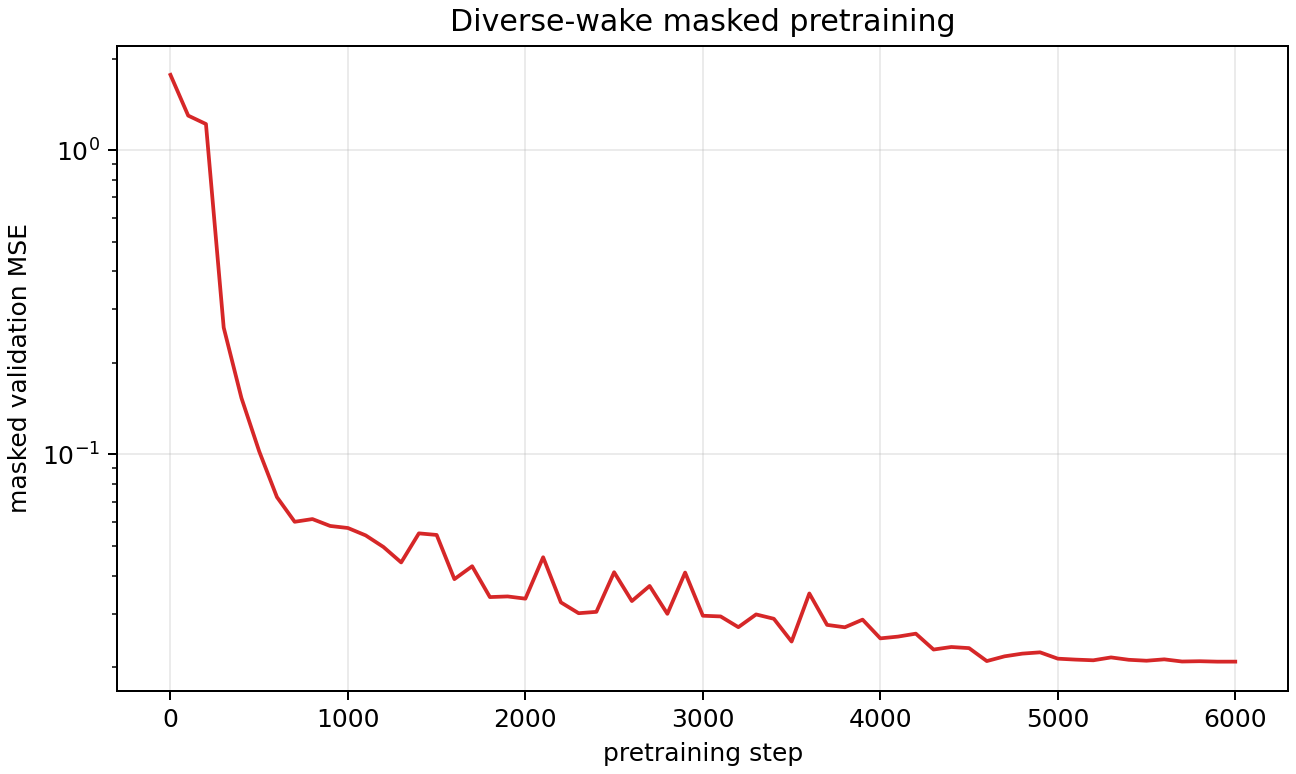

In [4]:
display(Image(filename=str(RESULTS/'pretraining_loss.png')))
print(metrics['model'])

## 3. Principal result: label efficiency on unseen trajectories

The curve aggregates labelled-frame draws within each trajectory, then reports
the mean and range across four independent test Reynolds cases.  This avoids
treating masks from one trajectory as independent flows.

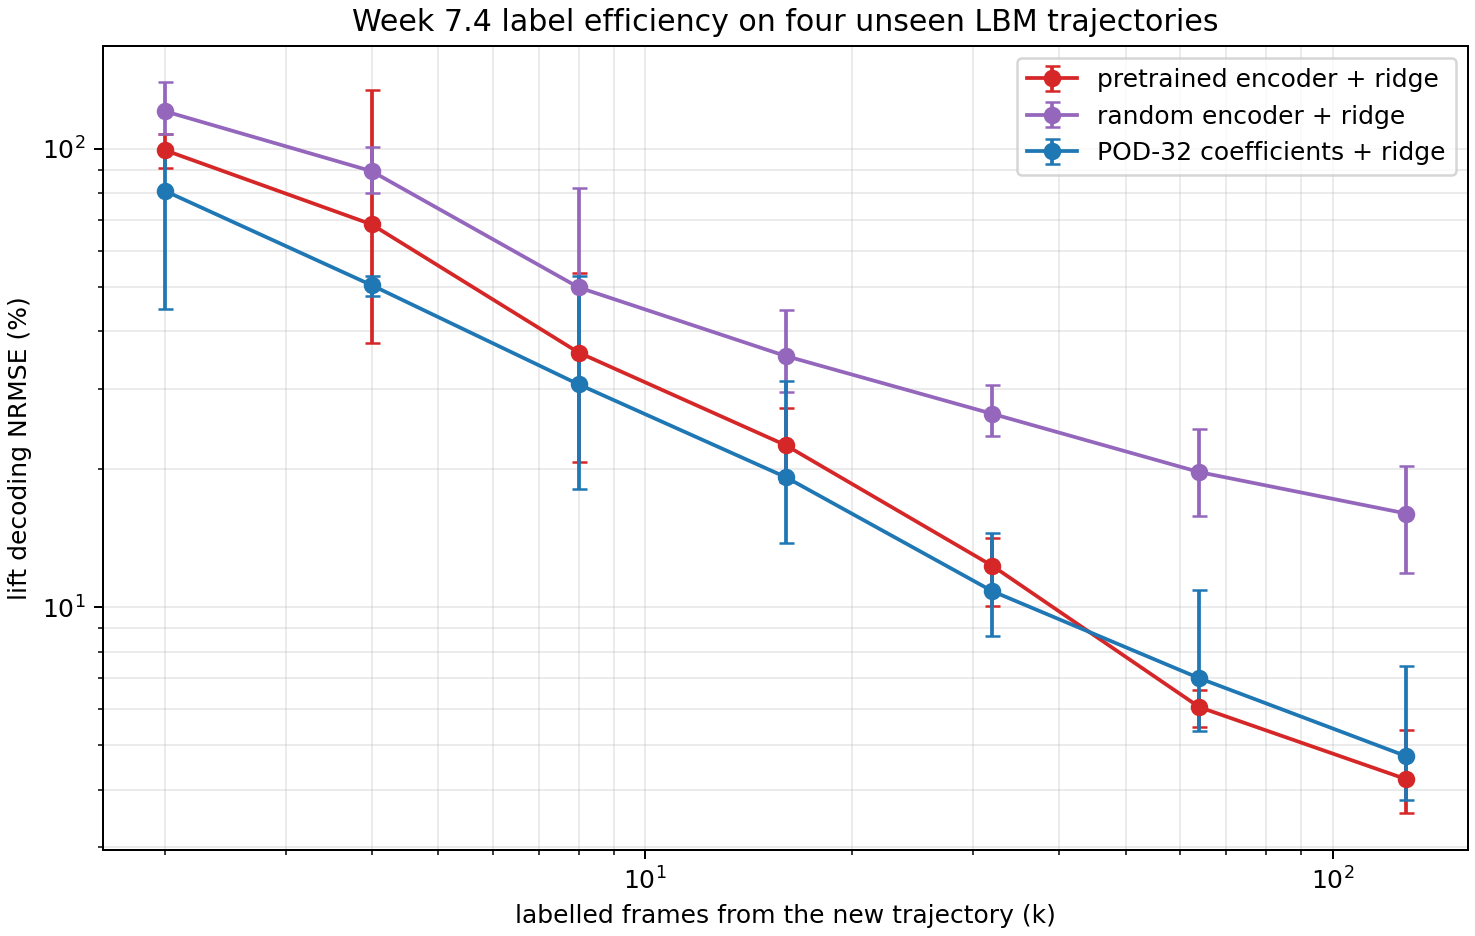

,k,pod32,pretrained_encoder,random_encoder
0,2,81.06,99.44,120.91
1,4,50.44,68.46,89.45
2,8,30.65,35.96,49.89
3,16,19.24,22.59,35.35
4,32,10.84,12.31,26.43
5,64,7.00,6.05,19.72
6,128,4.73,4.22,16.02


method        pod32  pretrained_encoder  random_encoder
reynolds k                                             
95       32   14.49               14.16           27.87
         64   10.89                6.57           24.44
         128   7.43                5.39           20.38
115      32   10.63               10.99           23.76
         64    6.14                6.60           15.82
         128   3.83                4.24           11.91
125      32    9.59               10.08           23.59
         64    5.38                5.55           18.29
         128   3.79                3.67           14.91
135      32    8.64               14.01           30.50
         64    5.59                5.49           20.33
         128   3.88                3.55           16.86

In [5]:
display(Image(filename=str(RESULTS/'label_efficiency.png')))
rows=[]
for k in protocol['ks']:
    rows.append({'k':k, **{m:metrics['curves'][m][str(k)]['mean'] for m in metrics['curves']}})
display(pd.DataFrame(rows).round(2))
records = pd.DataFrame(metrics['records'])
per_case = records.groupby(['reynolds','k','method'])['nrmse'].mean().unstack('method')
display(per_case.loc[(slice(None), [32,64,128]), :].round(2))

## 4. One untouched trajectory

Re115 below was not used for architecture, stopping, POD rank or ridge strength.
All methods use the same 32 early labels; the displayed window is separated by
the frozen gap.

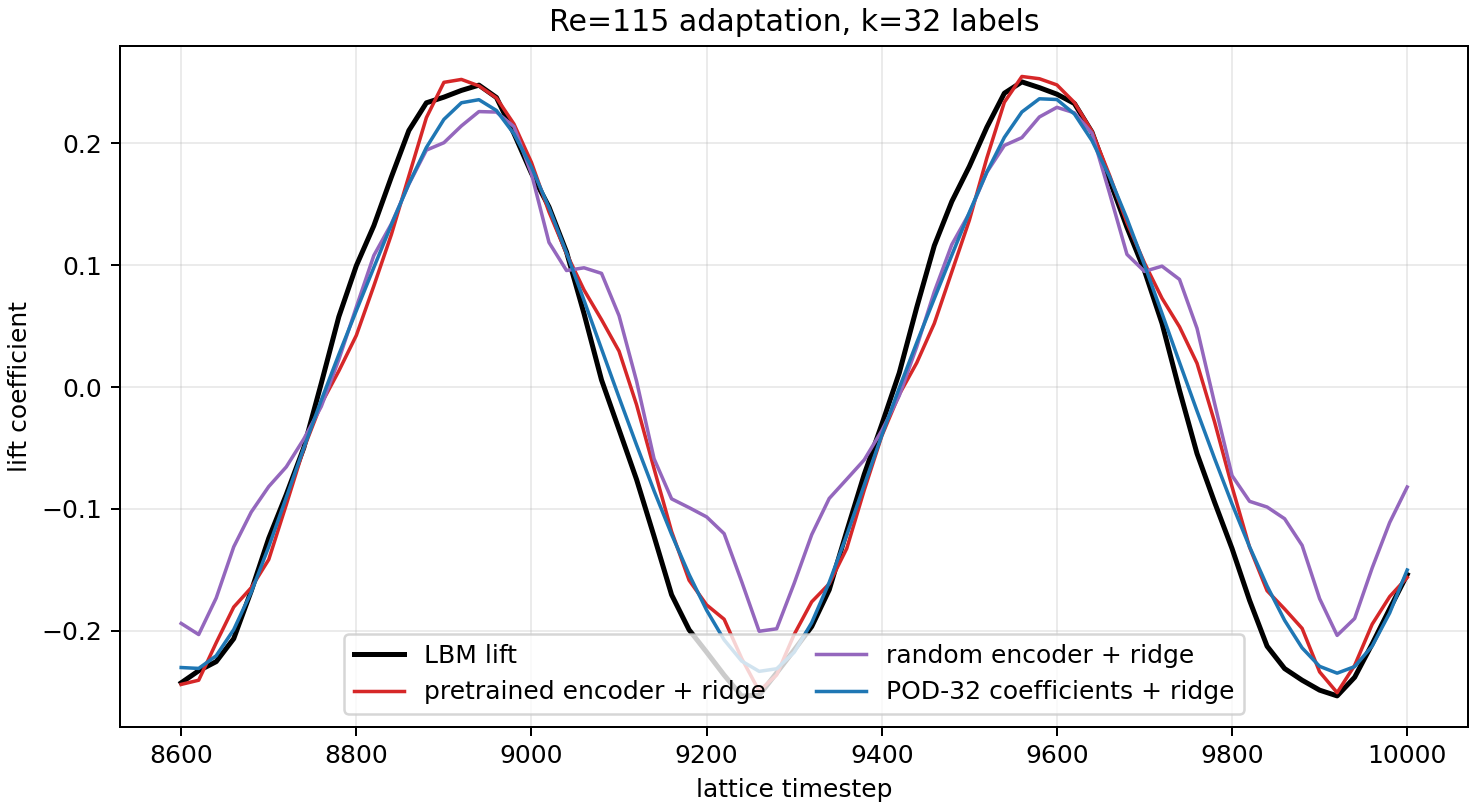

In [6]:
display(Image(filename=str(RESULTS/'re115_lift_decoding.png')))

## 5. Reading the evidence honestly

The pretrained encoder beats the random encoder at every k.  Its 12.31% NRMSE
at k=32 is already below the random encoder's 16.02% at k=128: better mean
accuracy with one-quarter as many target labels. POD remains better through k=32;
pretraining passes it only at k=64 and 128. These are quick educational LBM
trajectories, not grid-independent DNS or a force-validation benchmark.
Only one encoder initialization was trained; the three seeds resample labels,
not pretraining. POD rank is fixed at 32 and is not optimized over ranks. Initial
condition and Reynolds number vary together, with one run per Reynolds number;
this does not isolate initial-condition generalization. The inspected test set
is now retained evidence and must not guide further tuning. Average superiority
is not a significance test or a guarantee for each trajectory.

### Exercises
1. Replace instantaneous lift with a five-snapshot-ahead target.
2. Add fixed 2D coordinate and relative-position encodings.
3. Repeat with a geometry or inlet-profile shift held out by family.
4. Compare representation CKA across Reynolds number and perturbation sign.